# EDA — część 1

W tym notebooku robimy pierwszy krok pod projekt ASI: wczytujemy dane z SQLite, patrzymy na typy i „dziwne” wartości, robimy proste czyszczenie i na końcu zapisujemy krótkie wnioski (na zaliczenie / raport z zajęć).

In [17]:
import os
import sqlite3
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

## Ladowanie danych

In [18]:
project_root = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
load_dotenv(project_root / ".env")

db_path_raw = os.getenv("DB_PATH")
if not db_path_raw:
    raise ValueError("Brak zmiennej DB_PATH w .env")

db_path = Path(db_path_raw)
if not db_path.is_absolute():
    db_path = project_root / db_path

if not db_path.exists():
    raise FileNotFoundError(f"Nie znaleziono bazy: {db_path}")

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query("SELECT * FROM diabetes", conn)

df.head()

Wczytano 768 rekordow z /home/jakub/Desktop/Edukacja/Studia/8sem/ASI/Projekt/ASI_PRO/data/diabetes.db


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Analiza typow danych

In [19]:
dtype_df = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_count": df.notna().sum().values,
    }
)

dtype_df

,column,dtype,non_null_count
0,Pregnancies,int64,768
1,Glucose,int64,768
2,BloodPressure,int64,768
3,SkinThickness,int64,768
4,Insulin,int64,768
5,BMI,float64,768
6,DiabetesPedigreeFunction,float64,768
7,Age,int64,768
8,Outcome,int64,768


## Analiza brakow danych

In [20]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_count,
        "missing_percent": missing_percent,
    }
)

missing_summary

,missing_count,missing_percent
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


## Czyszczenie danych

In [21]:
df_clean = df.copy()

zero_as_missing_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

for col in zero_as_missing_cols:
    df_clean[col] = df_clean[col].replace(0, pd.NA)

missing_after_zero_replacement = df_clean[zero_as_missing_cols].isna().sum()
missing_after_zero_replacement

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [22]:
for col in zero_as_missing_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

clean_missing_summary = df_clean.isna().sum().sort_values(ascending=False)
clean_missing_summary.head(10)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Co wyszło na szybko

- W oryginalnej tabeli prawie nie ma klasycznych `NaN`, ale są **zera** w kolumnach typu glukoza, ciśnienie itd. — u nas (i w dalszym kodzie) traktujemy je jak brak pomiaru, nie jak prawdziwe 0.
- Po zamianie zer na „brak” najczęściej „dziurawy” jest `Insulin` i `SkinThickness`.
- Uzupełniamy medianą, żeby nie wyrzucać połowy wierszy — na ten etap EDA to nam wystarcza.

## Wnioski — część 1

- Dane da się normalnie wczytać z SQLite; ścieżka do bazy bierzemy z `.env` (`DB_PATH`), żeby nie hardcodować lokalnych ścieżek.
- Największy problem to te **zera** w cechach medycznych — bez tego kroku model by się mylił.
- Po naszym czyszczeniu i imputacji zbiór jest OK na kolejne wykresy i potem na model (w sprintcie 2 przenosimy to już do Kedro).

## EDA — część 2 (wykresy)

Teraz bierzemy już wyczyszczony `df_clean` i robimy wykresy: rozkłady, outliery, korelacje itd., żeby zobaczyć co w ogóle ma sens przed modelem. Zmienna celu to jak zwykle `Outcome` (0 / 1).

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")

### 1. Balans klas (`Outcome`)

Najpierw zwykły countplot — czy mamy mniej więcej tyle samo chorych i zdrowych, czy jedna klasa dominuje (to potem ważne przy metrykach).

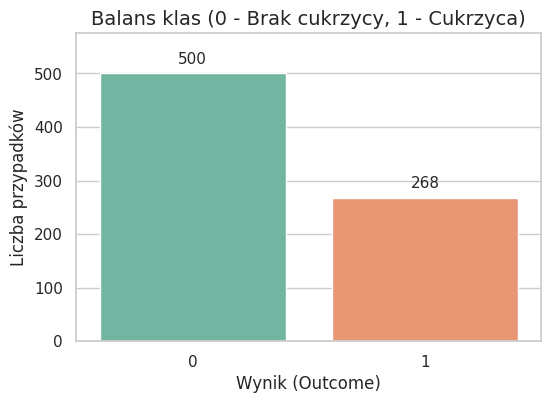

In [24]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df_clean, x="Outcome", palette="Set2", hue="Outcome", legend=False
)
plt.title("Balans klas (0 - Brak cukrzycy, 1 - Cukrzyca)", fontsize=14)
plt.xlabel("Wynik (Outcome)", fontsize=12)
plt.ylabel("Liczba przypadków", fontsize=12)

# Dodanie wartości liczbowych nad słupkami
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)
plt.show()

**Co z tego wynika:** widać od razu, że **klasa 0 jest liczniejsza** — orientacyjnie coś koło proporcji 2:1 względem jedynek. Przy ocenie modelu samo **accuracy** może być mylące, więc warto patrzeć też na **precision / recall / F1** (albo później bawić się wagami klas — na zajęciach o tym było).

### 2. Histogramy cech

Rzucamy okiem na rozkłady liczbowe — czy coś jest mocno skosne, czy wygląda „prawie normalnie”, itd.

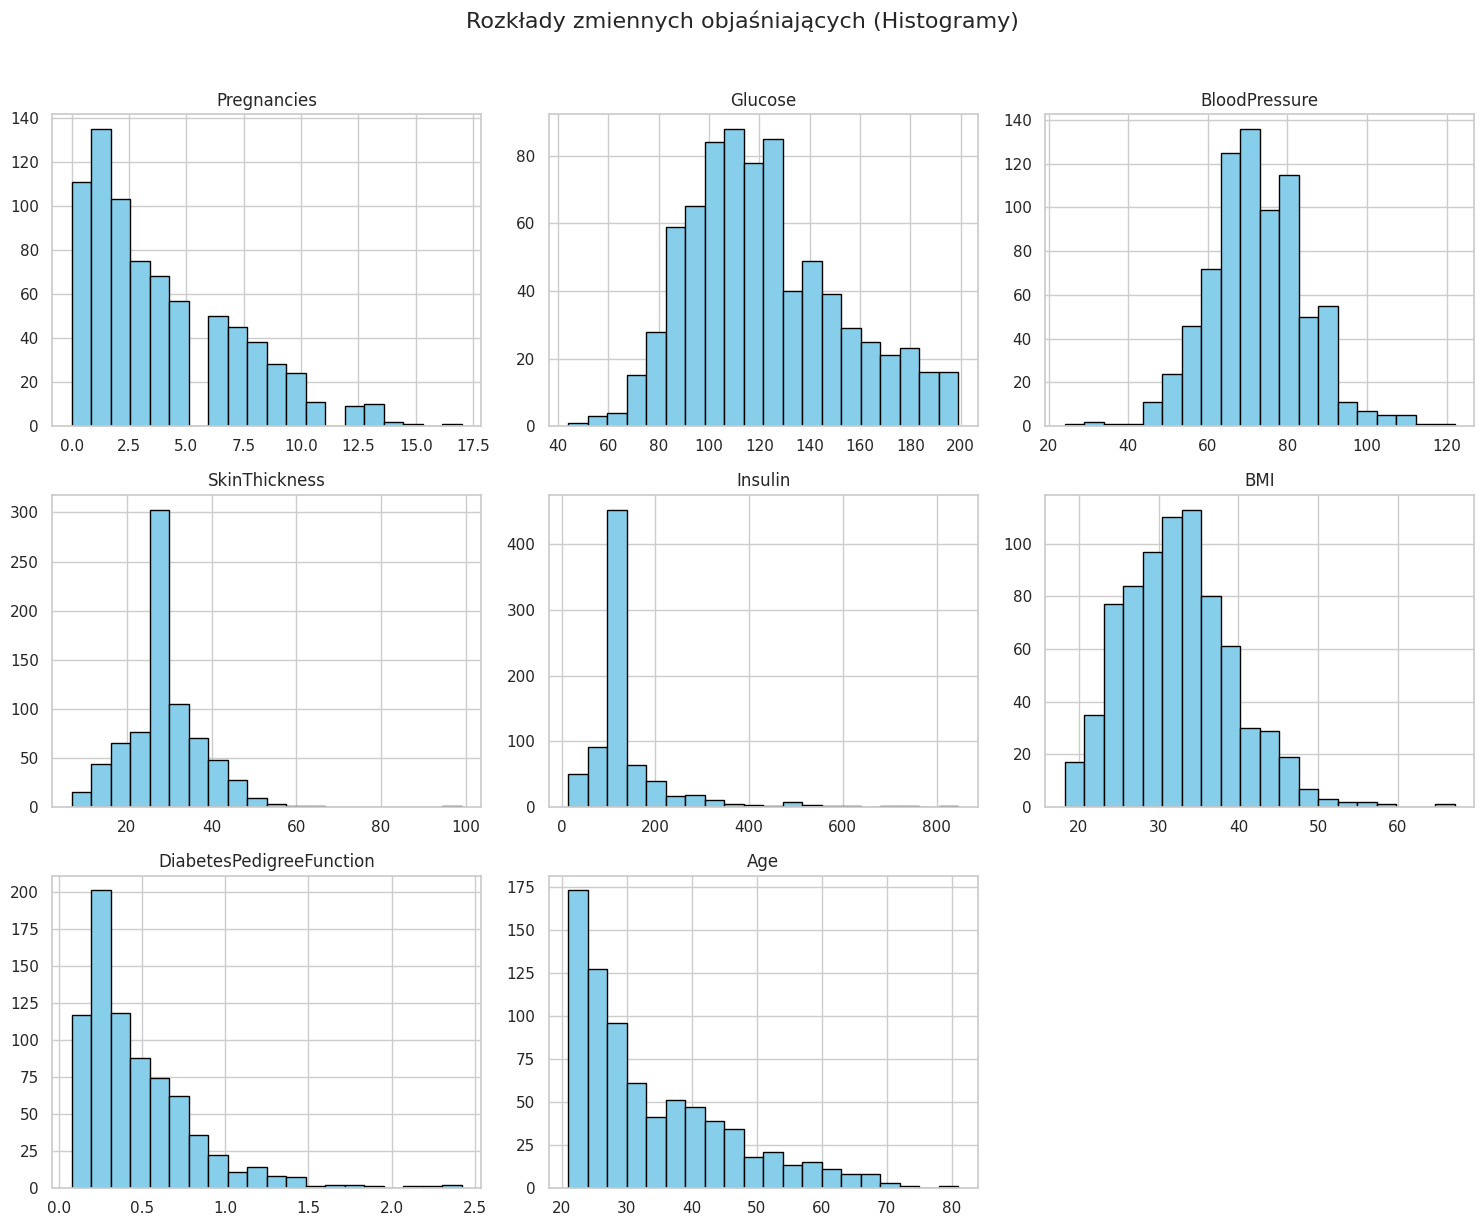

In [25]:
df_clean.drop("Outcome", axis=1).hist(
    bins=20, figsize=(15, 12), color="skyblue", edgecolor="black"
)
plt.suptitle("Rozkłady zmiennych objaśniających (Histogramy)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Co widać:** `BloodPressure` i `BMI` jakoś tam przypominają rozkład „dzwonkowy”. Za to `Age`, `Pregnancies`, `Insulin`, `DiabetesPedigreeFunction` są **mocno przesunięte w prawo** — większość ludzi jest młodsza / z mniejszymi wartościami, a potem są pojedyncze duże obserwacje (ogon po prawej).

### 3. Boxploty / outliery

Boxploty żeby zobaczyć „wąsy” i kropki ponad — czyli typowe outliery bez liczenia wszystkiego ręcznie.


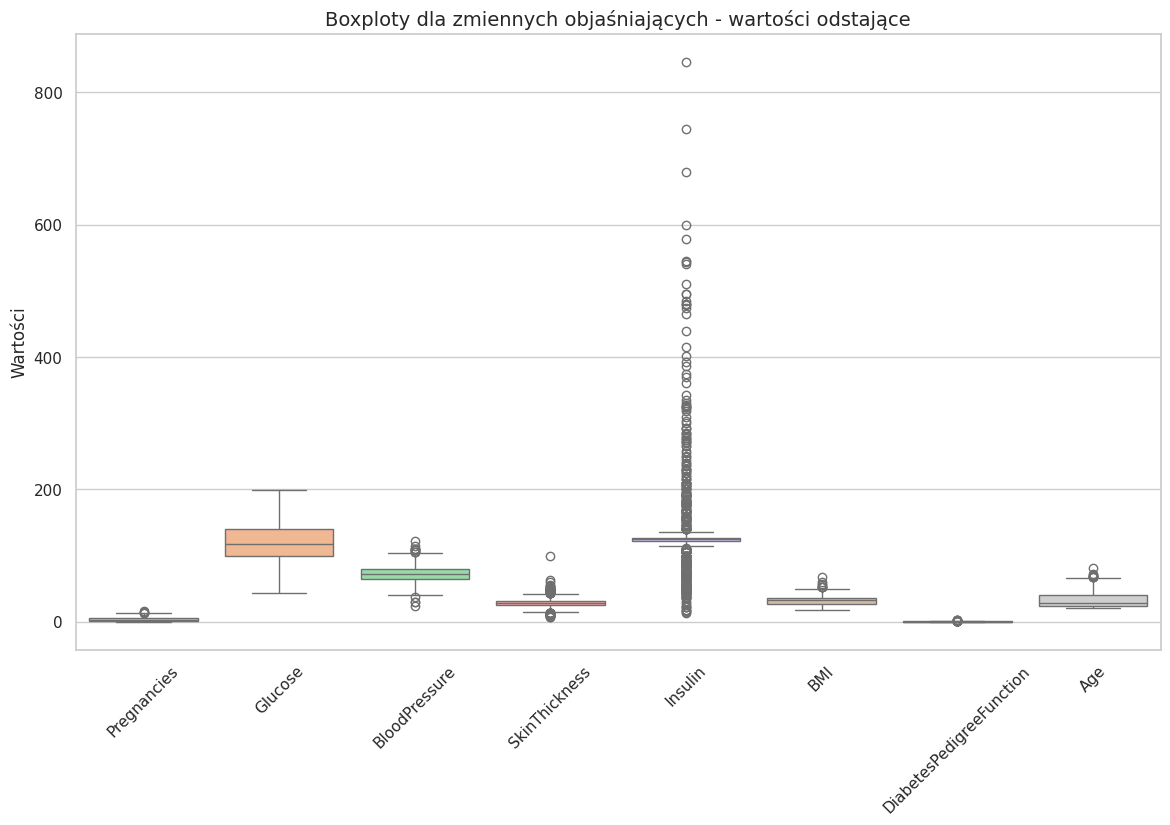

In [26]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_clean.drop("Outcome", axis=1), palette="pastel")
plt.title("Boxploty dla zmiennych objaśniających - wartości odstające", fontsize=14)
plt.ylabel("Wartości", fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Co z tego:** jest sporo kropek ponad wąsami — najbardziej „odjazdowa” jest `Insulin` (tam i tak wariancja jest duża). Coś podobnego widać też przy `DiabetesPedigreeFunction` i częściowo `BloodPressure`. Jakbyśmy szli w model bardzo czuły na outliery (np. zwykła logistyczna), to pewnie trzeba by było jeszcze przeskalować albo przetransformować kolumny — na razie tylko zapisujemy obserwację.

### 4. Korelacje (heatmapa)

Heatmapa Pearsona — co z czym rośnie i co ma sens z `Outcome`. Szukamy głównie podpowiedzi „co może być ważne w modelu”.

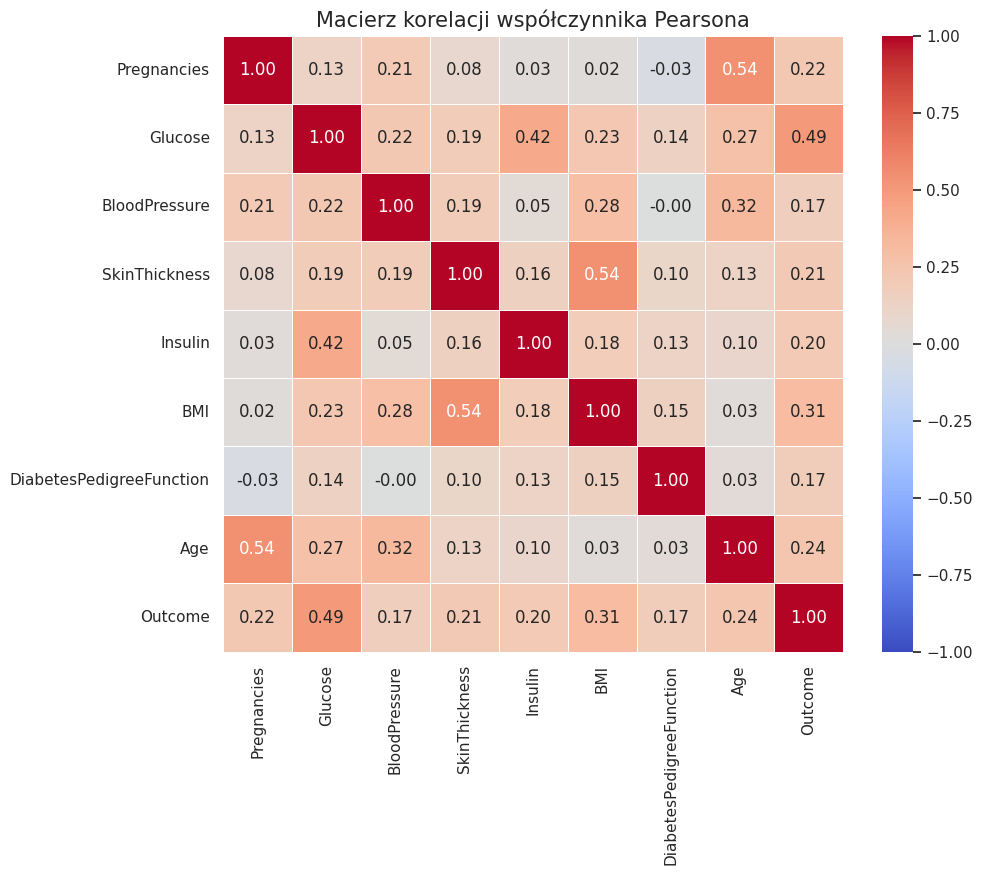

In [27]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.corr()
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Macierz korelacji współczynnika Pearsona", fontsize=15)
plt.show()

**W skrócie:** z `Outcome` najbardziej „idzie w parze” **Glucose** (u nas wychodzi ok. 0.49) — to się zgadza z sensownym podejściem medycznym i pewnie będzie głównym predyktorem.  
`Age` i `Pregnancies` też są ze sobą skorelowane (~0.5) — logiczne.  
Nie widzimy super wysokich korelacji **>0.8** między cechami wejściowymi, więc na ten moment nie wygląda na to, żebyśmy mieli mocną współliniowość „do poprawek” przed prostszymi modelami.

### 5. Pairplot (kilka cech naraz)

Na koniec pairplot na kilku kolumnach, które wyglądały sensownie z korelacji — kolorem rozróżniamy klasy (cukrzyca / brak).

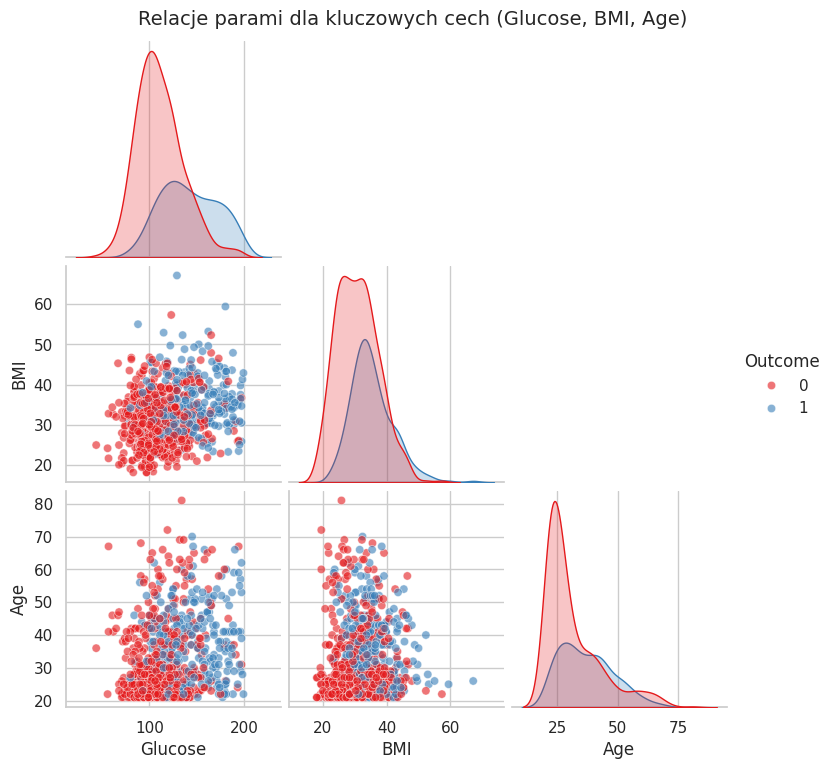

In [28]:
# Wybieramy kluczowe kolumny dla czytelności wykresu
cols_to_plot = ["Glucose", "BMI", "Age", "Outcome"]
sns.pairplot(
    df_clean[cols_to_plot],
    hue="Outcome",
    palette="Set1",
    corner=True,
    plot_kws={"alpha": 0.6},
)
plt.suptitle(
    "Relacje parami dla kluczowych cech (Glucose, BMI, Age)", y=1.02, fontsize=14
)
plt.show()

**Co widać na scatterach:** jedynki (cukrzyca) częściej siedzą przy **wyższej glukozie** i **wyższym BMI**, ale nadal jest sporo „nachodzenia” na zera — nie da się tego ładnie rozciąć jedną linią prostą.

---

### Wnioski — część 2 (po wykresach)

1. **Klasy:** jest więcej zer niż jedynek (u nas to mniej więcej ~65% vs ~35% — dokładnie widać na słupku).
2. **Co wygląda na ważne:** na pierwszy ogień **Glucose**, potem w praktyce też **BMI** i **Age** (to się zgadza z korelacjami).
3. **Śmieci / skośność:** `Insulin` i `DiabetesPedigreeFunction` są „rozjeżdżone” i mają outliery — trzeba o tym pamiętać przy kolejnych krokach.
4. **Model:** nie wygląda na to, żeby prosta granica liniowa załatwiła sprawę — stąd sensowne są np. **drzewa / lasy** (co potem robimy w baseline i w Kedro).
